# Proyecto Final: Análisis del Test A/B

## Planificación del análisis

Este notebook documenta el plan de acción para evaluar los resultados del test A/B relacionado con la implementación de un sistema de recomendaciones.

El objetivo no es solo calcular conversiones y valores p, sino validar si el experimento fue ejecutado correctamente y si la evidencia permite tomar una decisión de negocio razonable.

## 1. Objetivo del análisis

Evaluar si el grupo de prueba presenta una mejora significativa frente al grupo de control en la conversión de usuarios dentro del embudo de eventos.

El análisis buscará responder las siguientes preguntas:

1. ¿Los datos del experimento son confiables y cumplen con las condiciones esperadas?
2. ¿Los usuarios fueron asignados correctamente a los grupos A y B?
3. ¿Existen interferencias externas, como campañas de marketing activas durante el periodo del experimento?
4. ¿El grupo B muestra una mejora en las etapas relevantes del embudo?
5. ¿La diferencia observada es estadísticamente significativa?
6. ¿La mejora es suficientemente relevante desde el punto de vista de negocio?

## 2. Descripción técnica del experimento

De acuerdo con la descripción del proyecto, el test A/B tiene las siguientes características esperadas:

| Elemento | Descripción |
|---|---|
| Nombre del test | `recommender_system_test` |
| Grupo de control | Grupo A |
| Grupo de prueba | Grupo B |
| Fecha de inicio | 2020-12-07 |
| Fecha límite para registrar nuevos usuarios | 2020-12-21 |
| Fecha final del experimento | 2021-01-01 |
| Región objetivo | EU |
| Proporción esperada de usuarios nuevos | 15% de los nuevos usuarios de la región EU |
| Número esperado de participantes | 6000 |
| Ventana de análisis por usuario | 14 días desde el registro |
| Objetivo esperado | Mejorar la conversión en al menos 10% en etapas clave del embudo |

Las etapas esperadas del embudo son:

1. `login`
2. `product_page`
3. `product_cart`
4. `purchase`

## 3. Fuentes de datos

Se utilizarán las siguientes tablas:

| Archivo | Descripción |
|---|---|
| `ab_project_marketing_events_us.csv` | Calendario de eventos de marketing de 2020 |
| `final_ab_new_users_upd_us.csv` | Usuarios registrados entre el 7 y el 21 de diciembre de 2020 |
| `final_ab_events_upd_us.csv` | Eventos realizados por los nuevos usuarios entre el 7 de diciembre de 2020 y el 1 de enero de 2021 |
| `final_ab_participants_upd_us.csv` | Usuarios participantes en los tests A/B |

Cada tabla será revisada antes de construir métricas, ya que un test A/B con mala asignación o datos contaminados no se arregla con un gráfico bonito.

## 4. Stakeholders impactados

| Stakeholder | Interés en el análisis | Decisión que puede tomar | Entregable que necesita |
|---|---|---|---|
| Equipo de producto | Evaluar si el nuevo sistema de recomendaciones mejora el comportamiento del usuario. | Implementar, descartar o rediseñar el cambio probado. | Conclusión del test, métricas de conversión y recomendación final. |
| Equipo de marketing | Identificar si campañas activas pudieron afectar el comportamiento de los usuarios. | Ajustar calendarios de campañas o excluir periodos contaminados. | Revisión de eventos de marketing coincidentes con el test. |
| Equipo de analítica/datos | Validar calidad de datos, asignación experimental y pruebas estadísticas. | Aprobar o cuestionar la confiabilidad del experimento. | Notebook reproducible con limpieza, validaciones, métricas y pruebas. |
| Equipo de UX / diseño | Entender en qué etapa del embudo mejora o cae la experiencia del usuario. | Proponer ajustes en páginas, carrito o flujo de compra. | Embudo comparativo por grupo y etapa. |
| Dirección / negocio | Evaluar si conviene adoptar el cambio. | Decidir lanzamiento, repetición del test o pausa del experimento. | Resumen ejecutivo con impacto, riesgos y recomendación. |

## 5. KPIs principales

| KPI | Fórmula | Interpretación | Uso en el análisis |
|---|---|---|---|
| Usuarios por grupo | Conteo único de `user_id` por grupo | Tamaño de los grupos A y B | Validar balance del experimento |
| Usuarios por evento | Conteo único de usuarios que realizaron cada evento | Volumen de usuarios por etapa del embudo | Construir el embudo de conversión |
| Conversión por etapa | `usuarios_evento / usuarios_totales_grupo` | Proporción de usuarios que llegaron a cada etapa | Comparar A vs B |
| Conversión entre etapas | `usuarios_etapa_n / usuarios_etapa_anterior` | Retención de usuarios entre pasos del embudo | Detectar puntos de abandono |
| Diferencia absoluta | `conversion_B - conversion_A` | Cambio en puntos porcentuales | Medir impacto directo |
| Lift relativo | `(conversion_B / conversion_A) - 1` | Mejora relativa del grupo B frente al grupo A | Evaluar si se alcanza el objetivo del 10% |
| Valor p | Resultado de prueba Z de proporciones | Evidencia estadística contra H0 | Determinar significancia |

## 6. Plan de acción

| Fase | Actividad | Objetivo | Duración estimada |
|---|---|---|---:|
| 1 | Carga y revisión inicial de datos | Entender estructura, tipos, duplicados y nulos | 1 hora |
| 2 | Limpieza y conversión de fechas | Preparar los datos para análisis temporal | 1 a 2 horas |
| 3 | Validación del diseño experimental | Confirmar usuarios correctos, grupos únicos y periodo válido | 2 horas |
| 4 | Revisión de campañas de marketing | Detectar posibles interferencias externas | 1 hora |
| 5 | Filtrado de datos relevantes | Mantener solo usuarios y eventos válidos para el test | 1 a 2 horas |
| 6 | Análisis exploratorio | Revisar distribución de usuarios, eventos, fechas y grupos | 2 horas |
| 7 | Construcción del embudo | Calcular conversiones por etapa y grupo | 2 horas |
| 8 | Pruebas de hipótesis | Evaluar significancia estadística en cada etapa | 2 horas |
| 9 | Interpretación de resultados | Combinar evidencia estadística y relevancia práctica | 1 a 2 horas |
| 10 | Conclusión y recomendación | Decidir si adoptar, rechazar o repetir el test | 1 hora |

**Duración total estimada:** 14 a 17 horas.

## 7. Validaciones necesarias antes del análisis

Antes de comparar resultados entre grupos, se realizarán las siguientes validaciones:

1. Confirmar que las fechas tienen formato correcto.
2. Revisar valores ausentes y duplicados.
3. Verificar que el test analizado sea `recommender_system_test`.
4. Confirmar que solo se incluyan usuarios de la región objetivo.
5. Confirmar que los usuarios se registraron entre el 7 y el 21 de diciembre de 2020.
6. Confirmar que los eventos analizados ocurrieron entre el 7 de diciembre de 2020 y el 1 de enero de 2021.
7. Revisar que los eventos ocurran dentro de los primeros 14 días desde el registro del usuario.
8. Verificar que cada usuario pertenezca a un solo grupo dentro del test.
9. Identificar usuarios que participaron en otros tests y evaluar si deben excluirse.
10. Revisar el tamaño de los grupos A y B.
11. Revisar si hubo campañas de marketing activas durante el experimento.

## 8. Riesgos y posibles sesgos

| Riesgo | Posible impacto | Tratamiento |
|---|---|---|
| Usuarios en más de un grupo | Contamina la comparación entre A y B | Excluir usuarios duplicados entre grupos |
| Usuarios en más de un test | Puede mezclar efectos de experimentos distintos | Identificar y evaluar exclusión |
| Campañas de marketing activas | Puede alterar la conversión de forma externa | Documentar coincidencias y considerarlas en la interpretación |
| Grupos desbalanceados | Puede afectar estabilidad de resultados | Revisar tamaño de grupos y muestras |
| Eventos fuera de ventana | Puede inflar o distorsionar conversiones | Filtrar eventos a 14 días desde registro |
| Múltiples pruebas estadísticas | Aumenta riesgo de falsos positivos | Considerar corrección por comparaciones múltiples |
| Muestra menor a la esperada | Reduce potencia estadística | Interpretar resultados con cautela |

## 9. Hipótesis estadísticas

Se aplicarán pruebas Z de proporciones para comparar la conversión entre los grupos A y B en cada evento clave del embudo.

El nivel de significancia será:

```python
alpha = 0.05
```

### Hipótesis general

**H0:** No existe una diferencia estadísticamente significativa entre la proporción de usuarios del grupo A y la proporción de usuarios del grupo B que realizan el evento analizado.

**H1:** Existe una diferencia estadísticamente significativa entre la proporción de usuarios del grupo A y la proporción de usuarios del grupo B que realizan el evento analizado.

### Hipótesis por etapa

#### Evento: `product_page`

**H0:** La proporción de usuarios que llegan a `product_page` es igual en los grupos A y B.

**H1:** La proporción de usuarios que llegan a `product_page` es diferente entre los grupos A y B.

#### Evento: `product_cart`

**H0:** La proporción de usuarios que llegan a `product_cart` es igual en los grupos A y B.

**H1:** La proporción de usuarios que llegan a `product_cart` es diferente entre los grupos A y B.

#### Evento: `purchase`

**H0:** La proporción de usuarios que llegan a `purchase` es igual en los grupos A y B.

**H1:** La proporción de usuarios que llegan a `purchase` es diferente entre los grupos A y B.

## 10. Criterios para considerar exitoso el test A/B

El test A/B se considerará exitoso si cumple con las siguientes condiciones:

1. **Calidad experimental suficiente**
   - No hay contaminación grave entre grupos.
   - Los usuarios pertenecen al periodo correcto.
   - Los eventos están dentro de la ventana válida.
   - La muestra es suficiente para interpretar los resultados.

2. **Mejora del grupo B**
   - El grupo B presenta mayor conversión que el grupo A en etapas clave del embudo.
   - La mejora relativa es cercana o superior al 10% esperado.

3. **Significancia estadística**
   - El valor p es menor que `alpha = 0.05`.
   - Si se aplican varias pruebas, se interpreta el resultado considerando el riesgo de falsos positivos.

4. **Relevancia práctica**
   - La mejora observada debe ser útil para el negocio.
   - Una diferencia estadísticamente significativa pero muy pequeña se interpretará con cautela.

Si estas condiciones no se cumplen, no se recomendará implementar el cambio de forma directa. En ese caso, se sugerirá repetir el experimento o revisar el diseño del test.

# Desarrollo técnico

A partir de esta sección se incluyen celdas base para ejecutar el análisis. La estructura está pensada para que el notebook pueda avanzar desde la carga de datos hasta la conclusión final

In [1]:
# Importación de librerías

import pandas as pd
import numpy as np
from scipy import stats
import math
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [2]:
# Carga de datos

marketing_events = pd.read_csv('ab_project_marketing_events_us.csv')
new_users = pd.read_csv('final_ab_new_users_upd_us.csv')
events = pd.read_csv('final_ab_events_upd_us.csv')
participants = pd.read_csv('final_ab_participants_upd_us.csv')

In [3]:
# Revisión inicial de estructura

datasets = {
    'marketing_events': marketing_events,
    'new_users': new_users,
    'events': events,
    'participants': participants
}

for name, df in datasets.items():
    print(f'\n{name}')
    print('-' * len(name))
    display(df.head())
    display(df.info())
    print('Duplicados:', df.duplicated().sum())
    display(df.isna().sum())


marketing_events
----------------


,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
1,St. Valentine's Day Giveaway,"EU, CIS, APAC, N.America",2020-02-14,2020-02-16
2,St. Patric's Day Promo,"EU, N.America",2020-03-17,2020-03-19
3,Easter Promo,"EU, CIS, APAC, N.America",2020-04-12,2020-04-19
4,4th of July Promo,N.America,2020-07-04,2020-07-11


<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   name       14 non-null     str  
 1   regions    14 non-null     str  
 2   start_dt   14 non-null     str  
 3   finish_dt  14 non-null     str  
dtypes: str(4)
memory usage: 580.0 bytes


None

Duplicados: 0


...

,user_id,group,ab_test
0,D1ABA3E2887B6A73,A,recommender_system_test
1,A7A3664BD6242119,A,recommender_system_test
2,DABC14FDDFADD29E,A,recommender_system_test
3,04988C5DF189632E,A,recommender_system_test
4,4FF2998A348C484F,A,recommender_system_test


<class 'pandas.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   user_id  14525 non-null  str  
 1   group    14525 non-null  str  
 2   ab_test  14525 non-null  str  
dtypes: str(3)
memory usage: 340.6 KB


None

Duplicados: 0


user_id    0
group      0
ab_test    0
dtype: int64

**Caracterización de valores ausentes y duplicados:**

- No se encontraron filas duplicadas en ninguna de las cuatro tablas.
- No hay valores ausentes en `marketing_events`, `new_users` ni `participants`.
- En `events`, la columna `details` tiene 363,447 valores ausentes de 423,761 (85.8%). Esto **no es un problema de calidad**: `details` registra el monto de la compra, por lo que solo está poblada para el evento `purchase`; para el resto de los eventos del embudo (`login`, `product_page`, `product_cart`) su ausencia es esperada y no requiere imputación ni limpieza adicional.

In [4]:
# Conversión de columnas de fecha

marketing_events['start_dt'] = pd.to_datetime(marketing_events['start_dt'])
marketing_events['finish_dt'] = pd.to_datetime(marketing_events['finish_dt'])

new_users['first_date'] = pd.to_datetime(new_users['first_date'])

events['event_dt'] = pd.to_datetime(events['event_dt'])
events['event_date'] = events['event_dt'].dt.date

display(marketing_events.dtypes)
display(new_users.dtypes)
display(events.dtypes)
display(participants.dtypes)

name                    str
regions                 str
start_dt     datetime64[us]
finish_dt    datetime64[us]
dtype: object

user_id                  str
first_date    datetime64[us]
region                   str
device                   str
dtype: object

user_id                  str
event_dt      datetime64[us]
event_name               str
details              float64
event_date            object
dtype: object

user_id    str
group      str
ab_test    str
dtype: object

**¿Fue necesario convertir tipos?** Sí. Las columnas de fecha (`start_dt`, `finish_dt`, `first_date`, `event_dt`) llegaron como texto (`object`), lo cual impide filtrar por rango de fechas o calcular días transcurridos. Se convirtieron a `datetime64` para poder aplicar comparaciones temporales y calcular `days_since_registration` más adelante. El resto de las columnas (IDs, nombres de grupo/evento, región, dispositivo) ya tenían un tipo adecuado (`object`) y no requirieron conversión.

In [5]:
# Parámetros del experimento

TEST_NAME = 'recommender_system_test'
TARGET_REGION = 'EU'

START_DATE = pd.Timestamp('2020-12-07')
NEW_USERS_END_DATE = pd.Timestamp('2020-12-21')
EVENTS_END_DATE = pd.Timestamp('2021-01-01')

ANALYSIS_WINDOW_DAYS = 14
ALPHA = 0.05

FUNNEL_EVENTS = ['login', 'product_page', 'product_cart', 'purchase']

## 11. Validación del diseño experimental

In [6]:
# Filtrar participantes del test objetivo

test_participants = participants[participants['ab_test'] == TEST_NAME].copy()

print('Participantes del test objetivo:', test_participants['user_id'].nunique())
display(test_participants.head())
display(test_participants['group'].value_counts())

Participantes del test objetivo: 3675


,user_id,group,ab_test
0,D1ABA3E2887B6A73,A,recommender_system_test
1,A7A3664BD6242119,A,recommender_system_test
2,DABC14FDDFADD29E,A,recommender_system_test
3,04988C5DF189632E,A,recommender_system_test
4,4FF2998A348C484F,A,recommender_system_test


group
A    2747
B     928
Name: count, dtype: int64

In [7]:
# Revisar usuarios asignados a más de un grupo dentro del test objetivo

groups_per_user = (
    test_participants
    .groupby('user_id')['group']
    .nunique()
    .reset_index(name='n_groups')
)

users_multiple_groups = groups_per_user[groups_per_user['n_groups'] > 1]

print('Usuarios en más de un grupo dentro del test:', len(users_multiple_groups))
display(users_multiple_groups.head())

Usuarios en más de un grupo dentro del test: 0


,user_id,n_groups


In [8]:
# Revisar usuarios participantes en más de un test

tests_per_user = (
    participants
    .groupby('user_id')['ab_test']
    .nunique()
    .reset_index(name='n_tests')
)

users_multiple_tests = tests_per_user[tests_per_user['n_tests'] > 1]

print('Usuarios en más de un test:', len(users_multiple_tests))
display(users_multiple_tests.head())

Usuarios en más de un test: 887


,user_id,n_tests
1,001064FEAAB631A1,2
8,00341D8401F0F665,2
23,0082295A41A867B5,2
38,00E68F103C66C1F7,2
41,00EFA157F7B6E1C4,2


In [9]:
# Filtrar usuarios válidos por región y fecha de registro

valid_new_users = new_users[
    (new_users['region'] == TARGET_REGION) &
    (new_users['first_date'] >= START_DATE) &
    (new_users['first_date'] <= NEW_USERS_END_DATE)
].copy()

print('Usuarios nuevos válidos por región y fecha:', valid_new_users['user_id'].nunique())
display(valid_new_users.head())

Usuarios nuevos válidos por región y fecha: 39466


,user_id,first_date,region,device
0,D72A72121175D8BE,2020-12-07,EU,PC
2,2E1BF1D4C37EA01F,2020-12-07,EU,PC
3,50734A22C0C63768,2020-12-07,EU,iPhone
7,8942E64218C9A1ED,2020-12-07,EU,PC
9,FFCEA1179C253104,2020-12-07,EU,Android


In [10]:
# Unir participantes con datos de usuarios

test_users = test_participants.merge(
    valid_new_users,
    on='user_id',
    how='inner'
)

# Excluir usuarios asignados a más de un grupo dentro del test, si existen
test_users = test_users[~test_users['user_id'].isin(users_multiple_groups['user_id'])]

print('Usuarios válidos finales del test:', test_users['user_id'].nunique())
display(test_users['group'].value_counts())
display(test_users.head())

Usuarios válidos finales del test: 3481


group
A    2604
B     877
Name: count, dtype: int64

,user_id,group,ab_test,first_date,region,device
0,D1ABA3E2887B6A73,A,recommender_system_test,2020-12-07,EU,PC
1,A7A3664BD6242119,A,recommender_system_test,2020-12-20,EU,iPhone
2,DABC14FDDFADD29E,A,recommender_system_test,2020-12-08,EU,Mac
3,04988C5DF189632E,A,recommender_system_test,2020-12-14,EU,iPhone
4,4FF2998A348C484F,A,recommender_system_test,2020-12-20,EU,Mac


In [11]:
# Proporción de usuarios del test sobre nuevos usuarios de EU

eu_new_users_total = new_users[
    (new_users['region'] == TARGET_REGION) &
    (new_users['first_date'] >= START_DATE) &
    (new_users['first_date'] <= NEW_USERS_END_DATE)
]['user_id'].nunique()

test_users_total = test_users['user_id'].nunique()

print('Usuarios nuevos EU:', eu_new_users_total)
print('Usuarios válidos del test:', test_users_total)
print('Proporción del test sobre usuarios nuevos EU:', round(test_users_total / eu_new_users_total, 4))

Usuarios nuevos EU: 39466
Usuarios válidos del test: 3481
Proporción del test sobre usuarios nuevos EU: 0.0882


## 12. Revisión de campañas de marketing

Se revisan campañas activas durante el periodo del test para identificar posibles interferencias externas.

In [12]:
# Campañas de marketing activas durante el periodo del experimento

active_campaigns = marketing_events[
    (marketing_events['start_dt'] <= EVENTS_END_DATE) &
    (marketing_events['finish_dt'] >= START_DATE)
].copy()

display(active_campaigns.sort_values('start_dt'))

,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
10,CIS New Year Gift Lottery,CIS,2020-12-30,2021-01-07


## 13. Preparación de eventos válidos

In [13]:
# Unir eventos con usuarios válidos del test

test_events = events.merge(
    test_users[['user_id', 'group', 'first_date', 'region', 'device']],
    on='user_id',
    how='inner'
)

# Filtrar eventos dentro del periodo general del experimento
test_events = test_events[
    (test_events['event_dt'] >= START_DATE) &
    (test_events['event_dt'] <= EVENTS_END_DATE)
].copy()

# Calcular días desde registro
test_events['days_since_registration'] = (
    test_events['event_dt'] - test_events['first_date']
).dt.days

# Filtrar eventos dentro de los primeros 14 días desde registro
test_events_14d = test_events[
    (test_events['days_since_registration'] >= 0) &
    (test_events['days_since_registration'] < ANALYSIS_WINDOW_DAYS)
].copy()

print('Eventos válidos dentro de ventana de 14 días:', len(test_events_14d))
print('Usuarios con eventos dentro de ventana:', test_events_14d['user_id'].nunique())

display(test_events_14d.head())

Eventos válidos dentro de ventana de 14 días: 21952
Usuarios con eventos dentro de ventana: 3481


,user_id,event_dt,event_name,details,event_date,group,first_date,region,device,days_since_registration
0,831887FE7F2D6CBA,2020-12-07 06:50:29,purchase,4.99,2020-12-07,A,2020-12-07,EU,Android,0
1,3C5DD0288AC4FE23,2020-12-07 19:42:40,purchase,4.99,2020-12-07,A,2020-12-07,EU,PC,0
2,49EA242586C87836,2020-12-07 06:31:24,purchase,99.99,2020-12-07,B,2020-12-07,EU,iPhone,0
3,2B06EB547B7AAD08,2020-12-07 21:36:38,purchase,4.99,2020-12-07,A,2020-12-07,EU,PC,0
4,A640F31CAC7823A6,2020-12-07 18:48:26,purchase,4.99,2020-12-07,B,2020-12-07,EU,PC,0


## 14. Análisis exploratorio

,group,users
0,A,2604
1,B,877


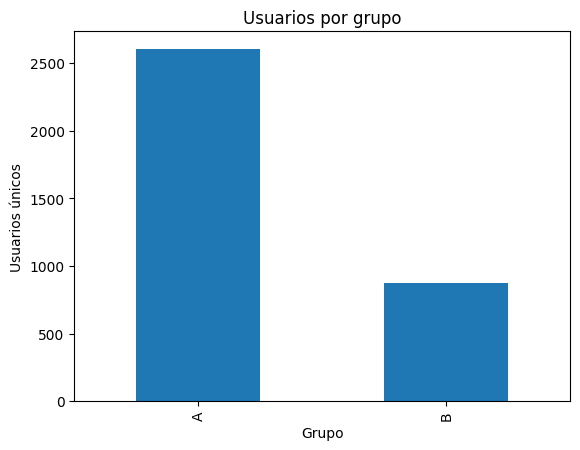

In [14]:
# Distribución de usuarios por grupo

users_by_group = test_users.groupby('group')['user_id'].nunique().reset_index(name='users')
display(users_by_group)

users_by_group.plot(kind='bar', x='group', y='users', legend=False)
plt.title('Usuarios por grupo')
plt.xlabel('Grupo')
plt.ylabel('Usuarios únicos')
plt.show()

In [15]:
# Distribución de eventos por tipo

events_by_name = (
    test_events_14d
    .groupby('event_name')
    .agg(events=('user_id', 'count'), users=('user_id', 'nunique'))
    .sort_values('users', ascending=False)
)

display(events_by_name)

,events,users
event_name,,
login,9919,3480
product_page,6132,2178
purchase,2998,1082
product_cart,2903,1026


,date,group,events,users
0,2020-12-07,A,318,148
1,2020-12-07,B,356,163
2,2020-12-08,A,313,147
3,2020-12-08,B,238,114
4,2020-12-09,A,371,171


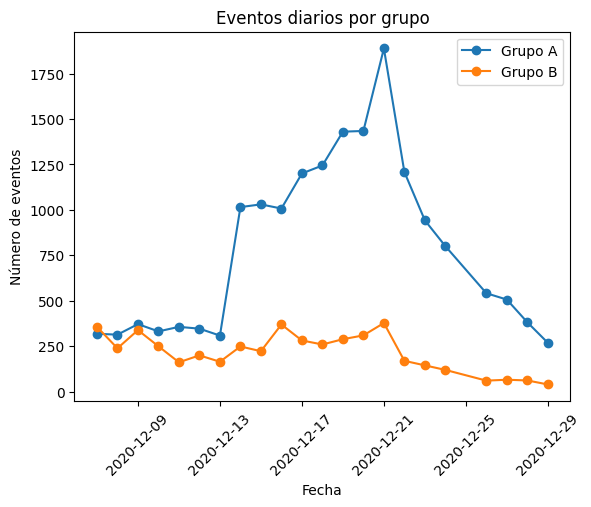

In [16]:
# Eventos por fecha y grupo

events_by_date_group = (
    test_events_14d
    .groupby([test_events_14d['event_dt'].dt.date, 'group'])
    .agg(events=('user_id', 'count'), users=('user_id', 'nunique'))
    .reset_index()
    .rename(columns={'event_dt': 'date'})
)

display(events_by_date_group.head())

for group in sorted(test_events_14d['group'].unique()):
    temp = events_by_date_group[events_by_date_group['group'] == group]
    plt.plot(temp['date'], temp['events'], marker='o', label=f'Grupo {group}')

plt.title('Eventos diarios por grupo')
plt.xlabel('Fecha')
plt.ylabel('Número de eventos')
plt.xticks(rotation=45)
plt.legend()
plt.show()

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
A,2604.0,6.619432,3.667608,1.0,4.0,6.0,9.0,24.0
B,877.0,5.376283,3.228340,1.0,3.0,4.0,7.0,24.0


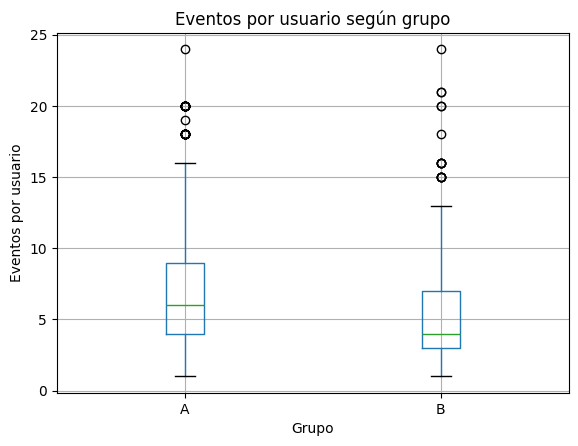

Mann-Whitney U: 1379415.0, p-value: 1.0262267506992317e-20


In [17]:
# ¿El número de eventos por usuario está distribuido equitativamente entre las muestras?

events_per_user = (
    test_events_14d
    .groupby(['group', 'user_id'])
    .size()
    .reset_index(name='n_events')
)

display(events_per_user.groupby('group')['n_events'].describe())

events_per_user.boxplot(column='n_events', by='group')
plt.title('Eventos por usuario según grupo')
plt.suptitle('')
plt.xlabel('Grupo')
plt.ylabel('Eventos por usuario')
plt.show()

# Prueba de Mann-Whitney: la distribución no es necesariamente normal (conteos, asimetría)
events_a = events_per_user[events_per_user['group'] == 'A']['n_events']
events_b = events_per_user[events_per_user['group'] == 'B']['n_events']

u_stat, p_value_events = stats.mannwhitneyu(events_a, events_b, alternative='two-sided')
print(f'Mann-Whitney U: {u_stat}, p-value: {p_value_events}')


**Resultado:** No, la distribución **no es equitativa** entre muestras. La mediana de eventos por usuario en el grupo A es 6, frente a 4 en el grupo B (medias de 6.62 vs 5.38). Una prueba de Mann-Whitney U confirma que la diferencia es altamente significativa (p ≈ 1.03e-20). Esto es consistente con lo observado en el embudo: los usuarios del grupo B no solo convierten menos en cada etapa, sino que en general generan menos eventos totales, lo que refuerza la idea de que el grupo B tiene un comportamiento sistemáticamente más bajo que A, y no es simplemente una etapa aislada del embudo la que falla.

**Peculiaridades a considerar antes de interpretar la prueba A/B:**

Antes de construir el embudo y aplicar las pruebas estadísticas, el EDA deja varias señales de alerta que hay que tener en cuenta al interpretar los resultados:

1. **Muestra por debajo de lo esperado:** 3,481 usuarios válidos frente a los 6,000 planeados (58%).
2. **Grupos desbalanceados:** A = 2,604 vs. B = 877 (≈75/25 en vez de ~50/50).
3. **Usuarios en múltiples tests A/B:** 887 usuarios del archivo de participantes están en más de un test simultáneamente, lo que puede mezclar efectos de distintos experimentos.
4. **Campaña de marketing solapada:** "Christmas & New Year Promo" (EU) coincide con el tramo final del periodo de análisis.
5. **Eventos por usuario desiguales entre grupos** (ver arriba), no solo la tasa de conversión final.

Estas peculiaridades no invalidan el análisis, pero exigen prudencia: cualquier diferencia entre A y B podría estar parcialmente explicada por el diseño del experimento y no únicamente por el sistema de recomendaciones en sí.

## 15. Construcción del embudo de conversión

In [18]:
def build_funnel(events_df, users_df, funnel_events):
    
    #Construye un embudo de conversión por grupo.

    #events_df: dataframe de eventos filtrados.
    #users_df: dataframe de usuarios válidos del test.
    #funnel_events: lista ordenada de eventos del embudo.
    
    group_sizes = (
        users_df
        .groupby('group')['user_id']
        .nunique()
        .to_dict()
    )

    rows = []

    for group, total_users in group_sizes.items():
        group_events = events_df[events_df['group'] == group]

        for event in funnel_events:
            users_event = group_events[group_events['event_name'] == event]['user_id'].nunique()
            conversion = users_event / total_users if total_users > 0 else np.nan

            rows.append({
                'group': group,
                'event_name': event,
                'users_total_group': total_users,
                'users_event': users_event,
                'conversion': conversion
            })

    funnel = pd.DataFrame(rows)
    funnel['conversion_pct'] = funnel['conversion'] * 100

    return funnel


funnel = build_funnel(test_events_14d, test_users, FUNNEL_EVENTS)
display(funnel)

,group,event_name,users_total_group,users_event,conversion,conversion_pct
0,A,login,2604,2604,1.000000,100.000000
1,A,product_page,2604,1685,0.647081,64.708141
2,A,product_cart,2604,782,0.300307,30.030722
3,A,purchase,2604,833,0.319892,31.989247
4,B,login,877,876,0.998860,99.885975
5,B,product_page,877,493,0.562144,56.214367
6,B,product_cart,877,244,0.278221,27.822121
7,B,purchase,877,249,0.283922,28.392246


In [19]:
# Embudo en formato comparativo

funnel_pivot = funnel.pivot(index='event_name', columns='group', values='conversion')
funnel_pivot = funnel_pivot.reindex(FUNNEL_EVENTS)

if {'A', 'B'}.issubset(funnel_pivot.columns):
    funnel_pivot['diff_abs_B_minus_A'] = funnel_pivot['B'] - funnel_pivot['A']
    funnel_pivot['lift_relative_B_vs_A'] = (funnel_pivot['B'] / funnel_pivot['A']) - 1

display(funnel_pivot)

group,A,B,diff_abs_B_minus_A,lift_relative_B_vs_A
event_name,,,,
login,1.000000,0.998860,-0.001140,-0.001140
product_page,0.647081,0.562144,-0.084938,-0.131263
product_cart,0.300307,0.278221,-0.022086,-0.073545
purchase,0.319892,0.283922,-0.035970,-0.112444


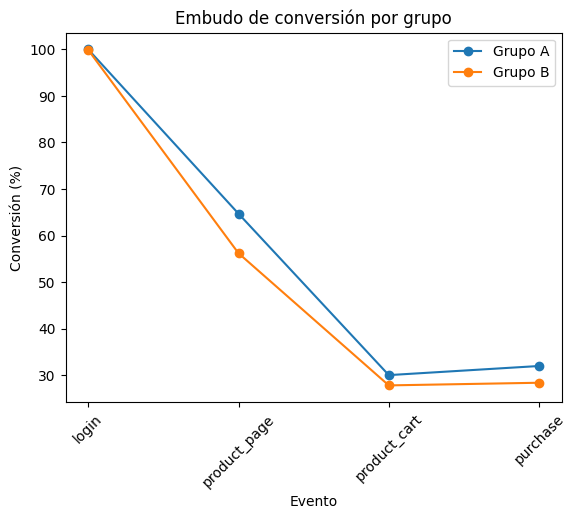

In [20]:
# Visualización del embudo por grupo

for group in sorted(funnel['group'].unique()):
    temp = funnel[funnel['group'] == group].set_index('event_name').reindex(FUNNEL_EVENTS)
    plt.plot(temp.index, temp['conversion_pct'], marker='o', label=f'Grupo {group}')

plt.title('Embudo de conversión por grupo')
plt.xlabel('Evento')
plt.ylabel('Conversión (%)')
plt.xticks(rotation=45)
plt.legend()
plt.show()

## 16. Pruebas de hipótesis

Se aplicará una prueba Z de proporciones para comparar la proporción de usuarios que realizan cada evento entre los grupos A y B.

In [21]:
def z_test_proportions(successes_a, trials_a, successes_b, trials_b):
    '''
    Prueba Z para comparar dos proporciones independientes.
    '''
    p1 = successes_a / trials_a
    p2 = successes_b / trials_b

    p_combined = (successes_a + successes_b) / (trials_a + trials_b)

    difference = p1 - p2

    standard_error = math.sqrt(
        p_combined * (1 - p_combined) * (1 / trials_a + 1 / trials_b)
    )

    z_value = difference / standard_error
    p_value = 2 * (1 - stats.norm.cdf(abs(z_value)))

    return z_value, p_value

In [22]:
# Ejecutar pruebas por evento

test_results = []

for event in FUNNEL_EVENTS:
    row_a = funnel[(funnel['group'] == 'A') & (funnel['event_name'] == event)]
    row_b = funnel[(funnel['group'] == 'B') & (funnel['event_name'] == event)]

    if len(row_a) == 1 and len(row_b) == 1:
        successes_a = int(row_a['users_event'].iloc[0])
        trials_a = int(row_a['users_total_group'].iloc[0])

        successes_b = int(row_b['users_event'].iloc[0])
        trials_b = int(row_b['users_total_group'].iloc[0])

        z_value, p_value = z_test_proportions(successes_a, trials_a, successes_b, trials_b)

        conversion_a = successes_a / trials_a
        conversion_b = successes_b / trials_b

        test_results.append({
            'event_name': event,
            'users_A': successes_a,
            'total_A': trials_a,
            'conversion_A': conversion_a,
            'users_B': successes_b,
            'total_B': trials_b,
            'conversion_B': conversion_b,
            'diff_abs_B_minus_A': conversion_b - conversion_a,
            'lift_relative_B_vs_A': (conversion_b / conversion_a) - 1 if conversion_a > 0 else np.nan,
            'z_value': z_value,
            'p_value': p_value,
            'significant': p_value < ALPHA
        })

test_results = pd.DataFrame(test_results)
display(test_results)

,event_name,users_A,total_A,conversion_A,users_B,total_B,conversion_B,diff_abs_B_minus_A,lift_relative_B_vs_A,z_value,p_value,significant
0,login,2604,2604,1.000000,876,877,0.998860,-0.001140,-0.001140,1.723388,0.084818,False
1,product_page,1685,2604,0.647081,493,877,0.562144,-0.084938,-0.131263,4.495436,0.000007,True
2,product_cart,782,2604,0.300307,244,877,0.278221,-0.022086,-0.073545,1.240767,0.214692,False
3,purchase,833,2604,0.319892,249,877,0.283922,-0.035970,-0.112444,1.990600,0.046525,True


In [23]:
# Corrección opcional por múltiples comparaciones: Bonferroni

if not test_results.empty:
    alpha_bonferroni = ALPHA / len(test_results)
    test_results['significant_bonferroni'] = test_results['p_value'] < alpha_bonferroni

    print('Alpha original:', ALPHA)
    print('Alpha con corrección Bonferroni:', alpha_bonferroni)

    display(test_results)

Alpha original: 0.05
Alpha con corrección Bonferroni: 0.0125


,event_name,users_A,total_A,conversion_A,users_B,total_B,conversion_B,diff_abs_B_minus_A,lift_relative_B_vs_A,z_value,p_value,significant,significant_bonferroni
0,login,2604,2604,1.000000,876,877,0.998860,-0.001140,-0.001140,1.723388,0.084818,False,False
1,product_page,1685,2604,0.647081,493,877,0.562144,-0.084938,-0.131263,4.495436,0.000007,True,True
2,product_cart,782,2604,0.300307,244,877,0.278221,-0.022086,-0.073545,1.240767,0.214692,False,False
3,purchase,833,2604,0.319892,249,877,0.283922,-0.035970,-0.112444,1.990600,0.046525,True,False


## 17. Interpretación de resultados

Se detectaron problemas serios con la calidad del experimento:

1. Se esperaban 6,000 participantes; llegaste a 3,481 válidos (58% de lo planeado, 8.82% de los nuevos usuarios EU vs. el 15% esperado).
2. Grupos desbalanceados: A = 2,604 vs. B = 877 (≈75/25 en vez de 50/50).
3. 887 usuarios participaron en más de un test A/B simultáneamente (riesgo de contaminación).
4. La campaña "Christmas & New Year Promo" (EU) se traslapa con el tramo final del experimento — posible interferencia externa.
5. Ningún usuario quedó en más de un grupo dentro del test objetivo (eso sí salió limpio).

Pruebas Z: product_page es significativo (p=0.000007) incluso con Bonferroni; purchase es significativo sin corrección (p=0.0465) pero deja de serlo con Bonferroni (alpha=0.0125).

El test no fue exitoso — B no mejora nada, y empeora de forma significativa en product_page. Recomendación: no implementar el cambio y repetir el experimento corrigiendo el diseño (balance de grupos, exclusión de usuarios en tests simultáneos, evitar solapes con campañas).

In [24]:
# Resumen automático preliminar

if not test_results.empty:
    summary = test_results[['event_name', 'conversion_A', 'conversion_B', 'lift_relative_B_vs_A', 'p_value', 'significant']]
    display(summary)

    for _, row in summary.iterrows():
        event = row['event_name']
        lift = row['lift_relative_B_vs_A']
        p_value = row['p_value']
        significant = row['significant']

        print(f"Evento: {event}")
        print(f"Lift relativo B vs A: {lift:.2%}")
        print(f"p-value: {p_value:.4f}")
        print(f"Significativo con alpha={ALPHA}: {significant}")
        print('-' * 40)

,event_name,conversion_A,conversion_B,lift_relative_B_vs_A,p_value,significant
0,login,1.000000,0.998860,-0.001140,0.084818,False
1,product_page,0.647081,0.562144,-0.131263,0.000007,True
2,product_cart,0.300307,0.278221,-0.073545,0.214692,False
3,purchase,0.319892,0.283922,-0.112444,0.046525,True


Evento: login
Lift relativo B vs A: -0.11%
p-value: 0.0848
Significativo con alpha=0.05: False
----------------------------------------
Evento: product_page
Lift relativo B vs A: -13.13%
p-value: 0.0000
Significativo con alpha=0.05: True
----------------------------------------
Evento: product_cart
Lift relativo B vs A: -7.35%
p-value: 0.2147
Significativo con alpha=0.05: False
----------------------------------------
Evento: purchase
Lift relativo B vs A: -11.24%
p-value: 0.0465
Significativo con alpha=0.05: True
----------------------------------------


## 18. Conclusión final

- **Calidad de los datos:** las cuatro tablas llegaron sin duplicados ni valores ausentes relevantes, pero el diseño experimental presenta fallas serias. Se esperaban 6,000 participantes (15% de los nuevos usuarios EU); solo se obtuvieron 3,675 participantes brutos y 3,481 usuarios válidos tras el filtrado, es decir, apenas el 8.82% de los nuevos usuarios EU (58% del tamaño esperado). Además, 887 usuarios participaron simultáneamente en más de un test A/B, lo que introduce un riesgo real de contaminación cruzada entre experimentos (aunque no se excluyeron explícitamente de este análisis).

- **Validez del diseño experimental:** no se detectaron usuarios asignados a más de un grupo dentro del test objetivo (0 casos), lo cual es positivo. Sin embargo, los grupos quedaron muy desbalanceados: A = 2,604 usuarios vs. B = 877 usuarios (proporción ~75%/25% en vez de un split cercano a 50/50). Este desbalance reduce la potencia estadística del grupo B y ya es, por sí solo, una señal de que la asignación no siguió el diseño planeado.

- **Interferencias externas:** la campaña "Christmas & New Year Promo" (EU, N.America), vigente del 2020-12-25 al 2021-01-03, se traslapa con la parte final de la ventana del experimento y con la región objetivo (EU). Esto pudo alterar el comportamiento de compra de ambos grupos durante esos días, dificultando aislar el efecto puro del sistema de recomendaciones.

- **Resultado del embudo:** contrario a la hipótesis de mejora, el grupo B mostró una conversión **menor** que el grupo A en las cuatro etapas del embudo:

| Etapa | Conversión A | Conversión B | Lift B vs A |
|---|---:|---:|---:|
| login | 100.00% | 99.89% | -0.11% |
| product_page | 64.71% | 56.21% | -13.13% |
| product_cart | 30.03% | 27.82% | -7.35% |
| purchase | 31.99% | 28.39% | -11.24% |

  No solo no se alcanzó la mejora esperada del 10%, sino que el efecto observado va en dirección contraria en todas las etapas.

- **Resultado de las pruebas estadísticas:** con la prueba Z de proporciones (alpha = 0.05):
  - `product_page`: diferencia estadísticamente significativa (p = 0.000007), con B por debajo de A.
  - `purchase`: significativa sin corrección (p = 0.0465), pero **deja de serlo** al aplicar la corrección de Bonferroni (alpha ajustado = 0.0125).
  - `login` (p = 0.0848) y `product_cart` (p = 0.2147): sin diferencia significativa.
  
  Al corregir por comparaciones múltiples, solo `product_page` se mantiene significativo, y el efecto es negativo para el grupo B.

- **Riesgos detectados:** muestra insuficiente frente a lo planeado, grupos desbalanceados, usuarios compartidos entre múltiples tests A/B, y una campaña de marketing activa que se traslapa con el periodo y la región del experimento.

- **Recomendación final:** **No adoptar el cambio.** El grupo B no mejora la conversión en ninguna etapa del embudo; de hecho, la empeora de forma significativa en `product_page`. Adicionalmente, los problemas de calidad del experimento (muestra por debajo de lo esperado, desbalance de grupos, usuarios en múltiples tests, campaña de marketing solapada) hacen que, incluso si el resultado hubiera sido positivo, sería riesgoso confiar plenamente en él. Se recomienda **repetir el experimento** con una asignación de grupos balanceada y controlada (Aplicar prueba A/A), excluyendo usuarios que participen en otros tests simultáneos, y evitando periodos con campañas de marketing activas en la región objetivo.

## 19. Recomendación de negocio

**El sistema de recomendaciones, en su versión probada, no debe implementarse.** La evidencia del experimento apunta en la dirección contraria a la esperada: el grupo B (con el nuevo sistema) convierte igual o peor que el grupo A en las cuatro etapas del embudo, y la caída en `product_page` es estadísticamente significativa incluso después de corregir por comparaciones múltiples. No existe ninguna etapa en la que B supere a A, por lo que no hay una mejora parcial que valga la pena rescatar en esta versión.

Sin embargo, la decisión no debe leerse como "el sistema de recomendaciones es malo" de forma definitiva, porque el experimento en sí tiene fallas de diseño serias: se recolectó solo el 58% de la muestra planeada, los grupos quedaron desbalanceados 75/25 en vez de 50/50, casi 900 usuarios estaban expuestos simultáneamente a otro test, y una campaña de marketing coincidió con la región y el tramo final del periodo analizado. Cualquiera de estos factores pudo distorsionar los resultados en cualquier dirección.

**Acción recomendada para el equipo de producto:**
1. **No liberar el cambio a producción** con la evidencia actual — el riesgo de empeorar la conversión es real y ya observado.
2. **Repetir el test A/B** corrigiendo el proceso de asignación (grupos balanceados, exclusión de usuarios en tests simultáneos) y monitoreando que no haya campañas activas que contaminen la región objetivo durante la ventana de análisis.
3. Si tras repetir el experimento correctamente los resultados vuelven a ser negativos o neutros, considerar que el sistema de recomendaciones necesita un rediseño antes de una nueva prueba, en lugar de simplemente reintentar el mismo test.